<a href="https://colab.research.google.com/github/nilupul99/Plant-Health-Monitor---Computer-Vision-CW/blob/main/CV_CW2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Data set

In [27]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kaustubhb999/tomatoleaf")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'tomatoleaf' dataset.
Path to dataset files: /kaggle/input/tomatoleaf


 List the contents of the dataset path

In [28]:
import os
print(os.listdir(path))

['tomato']


In [29]:
tomato_path = os.path.join(path, 'tomato')
print(os.listdir(tomato_path))

['cnn_train.py', 'val', 'train']


In [30]:
train_path = os.path.join(tomato_path, 'train')
print(os.listdir(train_path))

['Tomato___Late_blight', 'Tomato___healthy', 'Tomato___Early_blight', 'Tomato___Septoria_leaf_spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Bacterial_spot', 'Tomato___Target_Spot', 'Tomato___Tomato_mosaic_virus', 'Tomato___Leaf_Mold', 'Tomato___Spider_mites Two-spotted_spider_mite']


Count only images

In [31]:
class_counts = {}
for class_name in os.listdir(train_path):
    class_path = os.path.join(train_path, class_name)
    if os.path.isdir(class_path):
        image_count = len([f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        class_counts[class_name] = image_count

#Print the class distribution
print("Class-wise image distribution in training set:")
for class_name, count in sorted(class_counts.items()):
    print(f"{class_name}: {count} images")

Class-wise image distribution in training set:
Tomato___Bacterial_spot: 1000 images
Tomato___Early_blight: 1000 images
Tomato___Late_blight: 1000 images
Tomato___Leaf_Mold: 1000 images
Tomato___Septoria_leaf_spot: 1000 images
Tomato___Spider_mites Two-spotted_spider_mite: 1000 images
Tomato___Target_Spot: 1000 images
Tomato___Tomato_Yellow_Leaf_Curl_Virus: 1000 images
Tomato___Tomato_mosaic_virus: 1000 images
Tomato___healthy: 1000 images


Validation set

In [32]:
val_path = os.path.join(tomato_path, 'val')

val_class_counts = {}
for class_name in os.listdir(val_path):
    class_path = os.path.join(val_path, class_name)
    if os.path.isdir(class_path):
        image_count = len([f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        val_class_counts[class_name] = image_count

# Print the class distribution for the validation set
print("Class-wise image distribution in validation set:")
for class_name, count in sorted(val_class_counts.items()):
    print(f"{class_name}: {count} images")

Class-wise image distribution in validation set:
Tomato___Bacterial_spot: 100 images
Tomato___Early_blight: 100 images
Tomato___Late_blight: 100 images
Tomato___Leaf_Mold: 100 images
Tomato___Septoria_leaf_spot: 100 images
Tomato___Spider_mites Two-spotted_spider_mite: 100 images
Tomato___Target_Spot: 100 images
Tomato___Tomato_Yellow_Leaf_Curl_Virus: 100 images
Tomato___Tomato_mosaic_virus: 100 images
Tomato___healthy: 100 images


Define image dimensions and batch size

In [33]:
import tensorflow as tf
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

print(f"TensorFlow version: {tf.__version__}")
print(f"Image height: {IMG_HEIGHT}, Image width: {IMG_WIDTH}, Batch size: {BATCH_SIZE}")

TensorFlow version: 2.19.0
Image height: 224, Image width: 224, Batch size: 32


In [34]:
import math
class_names = sorted(os.listdir(train_path))
num_classes = len(class_names)

print(f"Number of classes: {num_classes}")
print(f"First class name: {class_names[0]}")

# 3. Load the raw training dataset
raw_train_ds = tf.keras.utils.image_dataset_from_directory(
    train_path,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=True
)

# Calculate total number of images in the raw_train_ds for splitting
total_train_images = sum(class_counts.values())

# 4. Determine the size of the test set and split the raw training dataset
test_split_ratio = 0.2
num_test_images = int(total_train_images * test_split_ratio)

# Calculate number of batches for test set
num_test_batches = math.ceil(num_test_images / BATCH_SIZE)

# Split raw_train_ds into train_ds and test_ds
train_ds = raw_train_ds.skip(num_test_batches)
test_ds = raw_train_ds.take(num_test_batches)

print(f"Total training images: {total_train_images}")
print(f"Images reserved for test set from training data: {num_test_images}")
print(f"Number of training batches: {len(train_ds)}")
print(f"Number of test batches: {len(test_ds)}")

# 5. Load the validation dataset
val_ds = tf.keras.utils.image_dataset_from_directory(
    val_path,
    labels='inferred',
    label_mode='int',
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(f"Number of validation batches: {len(val_ds)}")


Number of classes: 10
First class name: Tomato___Bacterial_spot
Found 10000 files belonging to 10 classes.
Total training images: 10000
Images reserved for test set from training data: 2000
Number of training batches: 250
Number of test batches: 63
Found 1000 files belonging to 10 classes.
Number of validation batches: 32


In [35]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

Normalize to [0, 1]

In [36]:
def preprocess(image, label):
    image = tf.image.resize(image, (IMG_HEIGHT, IMG_WIDTH))
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

In [37]:
train_ds = train_ds.map(preprocess)
val_ds = val_ds.map(preprocess)
test_ds = test_ds.map(preprocess)

In [38]:
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))

Prefetching and Caching

In [39]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [40]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

Sample Images

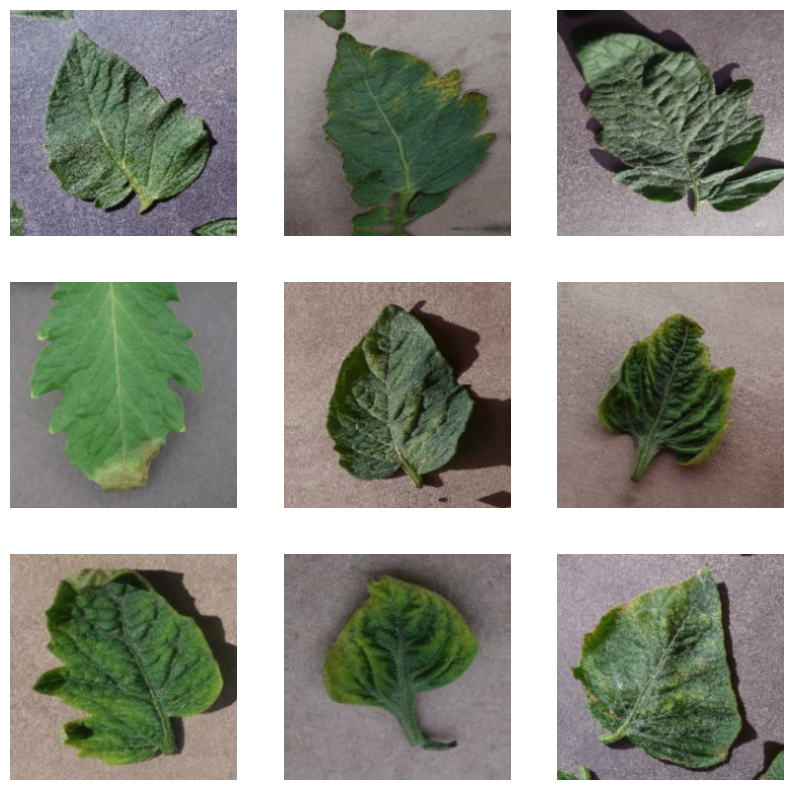

In [41]:
import matplotlib.pyplot as plt
images, labels = next(iter(train_ds))

plt.figure(figsize=(10,10))
for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.axis("off")
plt.show()

MobileNetV2 model training

In [42]:
base_model = MobileNetV2(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
                         include_top=False,
                         weights='imagenet')

In [43]:
base_model.trainable = False

In [44]:
classification_head = tf.keras.Sequential([
    GlobalAveragePooling2D(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

In [45]:
inputs = tf.keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))
x = base_model(inputs, training=False)
outputs = classification_head(x)
model = tf.keras.Model(inputs, outputs)

In [46]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

In [47]:
EPOCHS = 5
history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    steps_per_epoch=30,  # Process only 30 batches per epoch (Fast!)
    validation_steps=10  # Process only 10 batches for validation
)

print(f"Model training completed for {EPOCHS} epochs.")

Epoch 1/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.2188 - loss: 2.1508 - val_accuracy: 0.4344 - val_loss: 1.5803
Epoch 2/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.4750 - loss: 1.5052 - val_accuracy: 0.5094 - val_loss: 1.4328
Epoch 3/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 43s 1s/step - accuracy: 0.6094 - loss: 1.1752 - val_accuracy: 0.5781 - val_loss: 1.1436
Epoch 4/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 42s 1s/step - accuracy: 0.6302 - loss: 1.0634 - val_accuracy: 0.6031 - val_loss: 1.0553
Epoch 5/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 41s 1s/step - accuracy: 0.6948 - loss: 0.9748 - val_accuracy: 0.5781 - val_loss: 1.0550
Model training completed for 5 epochs.


In [48]:
test_loss, test_accuracy = model.evaluate(test_ds)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 57s 906ms/step - accuracy: 0.7316 - loss: 0.8596

Test Loss: 0.8596
Test Accuracy: 0.7316


 Classification report

In [49]:
import numpy as np
from sklearn.metrics import classification_report

predictions = model.predict(test_ds)
predicted_classes = np.argmax(predictions, axis=1)

true_labels = []
for _, labels in test_ds:
    true_labels.extend(labels.numpy())

print("\nClassification Report:")
print(classification_report(true_labels, predicted_classes, target_names=class_names))

63/63 ━━━━━━━━━━━━━━━━━━━━ 57s 893ms/step

Classification Report:
                                               precision    recall  f1-score   support

                      Tomato___Bacterial_spot       0.83      0.68      0.75       228
                        Tomato___Early_blight       0.64      0.43      0.51       206
                         Tomato___Late_blight       0.79      0.70      0.74       194
                           Tomato___Leaf_Mold       0.64      0.79      0.71       180
                  Tomato___Septoria_leaf_spot       0.53      0.82      0.65       200
Tomato___Spider_mites Two-spotted_spider_mite       0.82      0.64      0.72       204
                         Tomato___Target_Spot       0.55      0.75      0.64       192
       Tomato___Tomato_Yellow_Leaf_Curl_Virus       0.93      0.90      0.92       210
                 Tomato___Tomato_mosaic_virus       0.97      0.73      0.83       204
                             Tomato___healthy       0.83      0

ResNet50 Model training

In [50]:
from tensorflow.keras.applications import ResNet50

In [51]:
base_model_resnet = ResNet50(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
                         include_top=False,
                         weights='imagenet')

base_model_resnet.trainable = False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [52]:
classification_head_resnet = tf.keras.Sequential([
    GlobalAveragePooling2D(),
    Dropout(0.2),
    Dense(num_classes, activation='softmax')
])

In [53]:
inputs_resnet = tf.keras.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3))
x_resnet = base_model_resnet(inputs_resnet, training=False)
outputs_resnet = classification_head_resnet(x_resnet)
model_resnet = tf.keras.Model(inputs_resnet, outputs_resnet)

In [54]:
model_resnet.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                     loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
                     metrics=['accuracy'])

In [ ]:
history_resnet = model_resnet.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    steps_per_epoch=30,  # Process only 30 batches per epoch (Fast!)
    validation_steps=10  # Process only 10 batches for validation
)

print(f"ResNet50 model training completed for {EPOCHS} epochs.")

Epoch 1/5
30/30 ━━━━━━━━━━━━━━━━━━━━ 188s 6s/step - accuracy: 0.1052 - loss: 2.4133 - val_accuracy: 0.0000e+00 - val_loss: 2.4313
Epoch 2/5
 6/30 ━━━━━━━━━━━━━━━━━━━━ 1:40 4s/step - accuracy: 0.0840 - loss: 2.4272

In [ ]:
test_loss_resnet, test_accuracy_resnet = model_resnet.evaluate(test_ds)
print(f"\nResNet50 Test Loss: {test_loss_resnet:.4f}")
print(f"ResNet50 Test Accuracy: {test_accuracy_resnet:.4f}")

In [ ]:
predictions_resnet = model_resnet.predict(test_ds)
print("Predictions made on the test dataset using ResNet50 model.")

Classification Report

In [ ]:
predicted_classes_resnet = np.argmax(predictions_resnet, axis=1)

print("\nClassification Report for ResNet50 model:")
print(classification_report(true_labels, predicted_classes_resnet, target_names=class_names))

Charts

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))

# Plot training & validation accuracy values for MobileNetV2
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='MobileNetV2 Train Accuracy')
plt.plot(history.history['val_accuracy'], label='MobileNetV2 Val Accuracy')
plt.plot(history_resnet.history['accuracy'], label='ResNet50 Train Accuracy')
plt.plot(history_resnet.history['val_accuracy'], label='ResNet50 Val Accuracy')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='lower right')

# Plot training & validation loss values for MobileNetV2
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='MobileNetV2 Train Loss')
plt.plot(history.history['val_loss'], label='MobileNetV2 Val Loss')
plt.plot(history_resnet.history['loss'], label='ResNet50 Train Loss')
plt.plot(history_resnet.history['val_loss'], label='ResNet50 Val Loss')
plt.title('Model Loss Comparison')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

### Image Prediction Setup

To identify the provided image, we need to load it, preprocess it to match the model's input requirements (resize and normalize), and then use our trained models (MobileNetV2 and ResNet50) to make predictions.

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

# Path to the image file
img_path = '/content/test image.jfif'

# Load and resize the image to the target size (IMG_HEIGHT, IMG_WIDTH)
img = image.load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH))

# Convert the image to a numpy array
img_array = image.img_to_array(img)

# Expand dimensions to create a batch size of 1 (expected by the model)
img_array = np.expand_dims(img_array, axis=0)

# Preprocess the image (normalize pixel values to [0, 1])
img_array = img_array / 255.0

print(f"Image loaded and preprocessed. Shape: {img_array.shape}")

Prediction with MobileNetV2

In [ ]:

mobilenetv2_predictions = model.predict(img_array)
mobilenetv2_predicted_class_index = np.argmax(mobilenetv2_predictions[0])
mobilenetv2_predicted_probability = mobilenetv2_predictions[0][mobilenetv2_predicted_class_index]
mobilenetv2_predicted_class_name = class_names[mobilenetv2_predicted_class_index]

print(f"\n--- MobileNetV2 Prediction ---")
print(f"Predicted class: {mobilenetv2_predicted_class_name}")
print(f"Confidence: {mobilenetv2_predicted_probability:.2%}")
print(f"\n*Recommendation (conceptual, via LLM integration): Based on this classification, an integrated LLM would provide actionable advice such as treatment options, preventive measures, or further diagnostic steps for '{mobilenetv2_predicted_class_name}'.")

Prediction with ResNet50

In [ ]:
resnet50_predictions = model_resnet.predict(img_array)
resnet50_predicted_class_index = np.argmax(resnet50_predictions[0])
resnet50_predicted_probability = resnet50_predictions[0][resnet50_predicted_class_index]
resnet50_predicted_class_name = class_names[resnet50_predicted_class_index]

print(f"\n--- ResNet50 Prediction ---")
print(f"Predicted class: {resnet50_predicted_class_name}")
print(f"Confidence: {resnet50_predicted_probability:.2%}")
print(f"\n*Note: ResNet50 showed significantly lower accuracy during evaluation (approx. {test_accuracy_resnet:.2%}). Its prediction for '{resnet50_predicted_class_name}' might be unreliable. An integrated LLM would also consider the model's confidence and overall performance when generating recommendations.")